# 2D FDTD with fdtdx: Plane Source & Cylinder

Currently, **FDTDX does not natively support true 2D simulations**. However, a 2D problem can still be simulated by constructing a very thin 3D domain and enforcing periodicity in the third dimension. This notebook demonstrates how to implement such a setup.

In this example, we simulate a **2D electromagnetic problem in the x–y plane**. The **x and y directions represent the actual physical simulation dimensions**, where the fields evolve and interact with objects. The **z direction does not represent a real physical dimension of the problem**. Instead, it acts as a small **buffer dimension required by the FDTDX solver**, which currently operates on 3D grids.

To emulate a 2D system, the computational domain is constructed as a **3-cell extrusion along the z-axis**:

- The simulation volume is **three cells thick in the z direction**.
- The **first and last cells in z (indices 0 and 2)** use **periodic boundary conditions**.
- All materials and structures are **uniform along the z direction**.

Because the geometry and material properties do not vary along z and periodic boundaries are enforced, the electromagnetic fields also remain invariant in that direction. As a result, the simulation effectively behaves as a **2D simulation in the x–y plane**, while the z dimension simply enables compatibility with the 3D FDTD implementation in FDTDX.

Note: Some special sources (mode / gaussian plane sources) may not currently work in this 2D trick. But a standard plane source does.

---

## Imports & Setup


In [41]:
import fdtdx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from IPython.display import HTML
from IPython.display import Video
%matplotlib inline


## Simulation Configuration

Here we define the basic simulation parameters:

- The **material type** and its **permittivity**.
- The **simulation configuration**, which includes parameters such as the simulation duration, spatial resolution, numerical precision (`dtype`), and the Courant stability factor.
- The **boundary conditions** used for the computational domain.

In [44]:
# 1) Basic FDTD config
config = fdtdx.SimulationConfig(
    time=100e-15,           # total simulated time
    resolution=50e-9,       # spatial resolution
    dtype=jnp.float32,
    courant_factor=0.99,
)

material = fdtdx.Material(permittivity=1.0)

materials = {
    "air": material,
    "cylinder": fdtdx.Material(permittivity=2.25),
}


# create a volume that is large in x/y, thin in z
volume = fdtdx.SimulationVolume(
    partial_real_shape=(8e-6, 4e-6, 0.3e-6),  # ~3 cells in z
    material=material
)

# --- Compute grid cell counts manually ---
dx = config.resolution
nx = int(volume.partial_real_shape[0] / dx)
ny = int(volume.partial_real_shape[1] / dx)
nz = int(volume.partial_real_shape[2] / dx)


We enforce **periodic boundary conditions along the z direction** (between the first and last grid slices). This ensures that the fields repeat in the z direction and therefore remain invariant, effectively reproducing a **2D simulation in the x–y plane**.

In FDTDX, periodicity can be defined through **boundary configuration objects**, although it can also be implemented manually if needed.


In [47]:
# create periodic boundaries in z
bound_cfg = fdtdx.BoundaryConfig.from_uniform_bound(
    thickness=1, 
    boundary_type="periodic"
)
bound_dict, bc_constraints = fdtdx.boundary_objects_from_config(bound_cfg, volume)


## Plane Source

Next, we place a **plane source** that emits light in the **+x direction** into the simulation domain.

For this setup, we use a standard `UniformPlaneSource`. Currently, **mode sources are not supported when using the 2D extrusion approach** described above.

The source is **extruded along the z direction**, meaning it is uniform across the thin buffer dimension. This maintains the effective 2D behavior of the simulation.

At this stage, we also initialize the lists for **objects** and **constraints**, which will allow us to easily append additional simulation components later.


In [50]:
from fdtdx import UniformPlaneSource, WaveCharacter

source = fdtdx.UniformPlaneSource(
fixed_E_polarization_vector=(0,0,1),
partial_grid_shape=(1, None, None),
partial_real_position=(0.0, None, None),  # x = 0, span y/z
wave_character=fdtdx.WaveCharacter(wavelength=1.55e-6),
direction="+",
name="plane_source",
)

objects = []
constraints = []

## Cylinder (Scatterer)

We place a **cylindrical scatterer** at the center of the simulation domain.

The cylinder extends fully along the **z direction**, which means that in the effective **2D x–y view it appears as a circle**.

In FDTDX, the `Cylinder` primitive is defined as a 3D object that is extruded along one axis (in this case the z axis). When used in the thin-domain setup described above, it therefore behaves like a **2D circular scatterer**.


In [53]:
cyl = fdtdx.Cylinder(
    partial_real_shape=(0.5e-6, 0.5e-6, 0.3e-6),
    radius=0.25e-6,
    axis=2,
    materials=materials,
    material_name="cylinder",
    name="cylinder",
)



Let's assemble all the objects and constraints in our lists.

In [56]:
# Assemble objects and constraints
objects.append(volume)
objects.append(source)

# add boundary objects + constraints (FIX)
for val in bound_dict.values():
    if isinstance(val, tuple):
        bound_obj, bound_constraint = val
        objects.append(bound_obj)
        constraints.append(bound_constraint)
    else:
        # periodic boundary (object only)
        objects.append(val)

# add cylinder + its constraint
objects.append(cyl)
constraints.append(cyl.place_at_center(volume))
constraints.extend(
    source.same_position_and_size(volume, axes=(1, 2))
)

In order to actually see a result from the simulation, we need to define a Detector.

Here we use an EnergyDetector, which calculates the energy at every grid point within its volume. We also speciy a switch, which controls the time steps that the detector records. Our purpose here is to generate a video of the energy during the simulation. We do not need every single time step for this, so we only record every fifth time step.

In [59]:
video_detector = fdtdx.EnergyDetector(
    name="Ez_video",
    switch=fdtdx.OnOffSwitch(interval=5)
)
objects.append(video_detector)
constraints.extend(video_detector.same_position_and_size(volume))

## Place Objects & Build Scene

Now compute actual positions for all objects.


In [62]:
key = jax.random.PRNGKey(42)
key, subkey = jax.random.split(key)

objs, arrays, params, config, _ = fdtdx.place_objects(
object_list=objects,
config=config,
constraints=constraints,
key=subkey,
)


<Figure size 800x600 with 0 Axes>

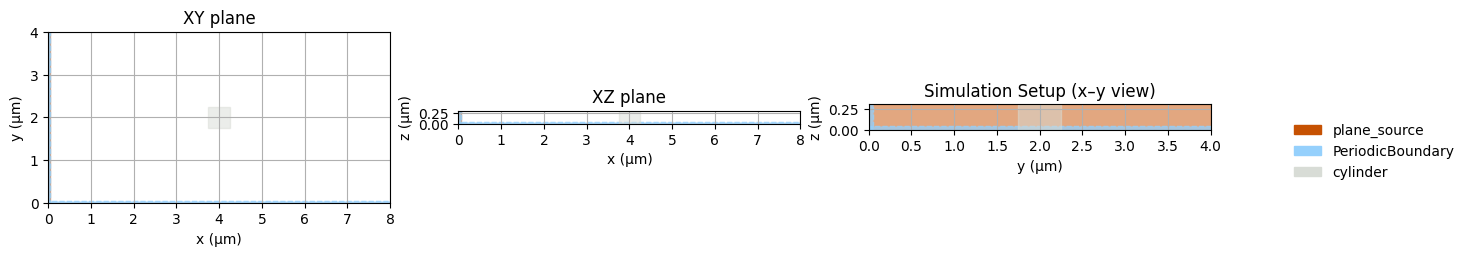

In [64]:
plt.figure(figsize=(8, 6))
fdtdx.plot_setup(config=config, objects = objs, exclude_object_list=[video_detector])
plt.title("Simulation Setup (x–y view)")
plt.show()

<Figure size 800x600 with 0 Axes>

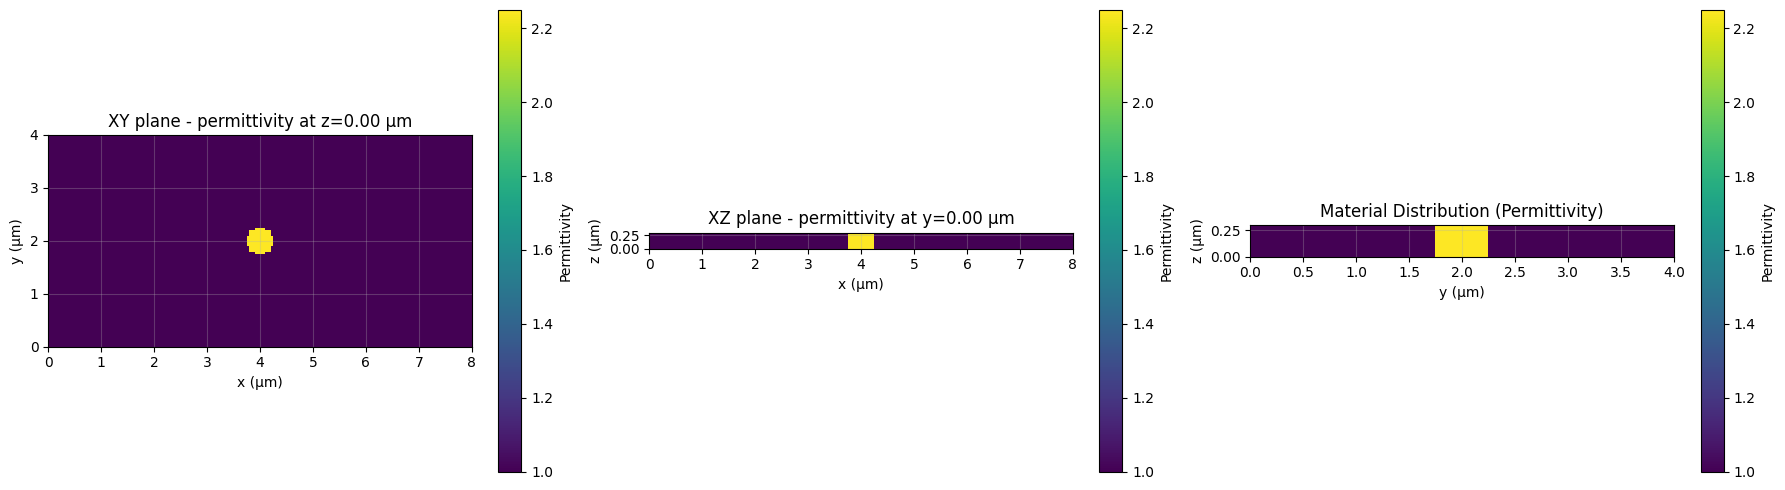

In [66]:
from fdtdx.utils.plot_material import plot_material


plt.figure(figsize=(8, 6))
plot_material(
    arrays=arrays,
    config=config,
)
plt.title("Material Distribution (Permittivity)")
plt.tight_layout()
plt.show()


## Running the Simulation

Now let's define a function that actually runs the simulation. In FDTDX, this is a two-part process.

Firstly, we call apply_params, which performs some calculations before the start of the simulation. If we have some parametric objects in the simulation, this function applies the given parameters and calculates the actual shapes of these objects. Additionally, some performance optimization are done here by calculating values for the simulation once before the simulation starts

Then, we call run_fdtd, which performs the FDTD simulation as a loop. The computation terminates as soon as the required number of time steps are reached.


In [69]:
key, subkey = jax.random.split(key)

arrays, new_objects, info = fdtdx.apply_params(arrays, objs, params, key)

final_timestamp, new_arrays = fdtdx.run_fdtd(
    config=config,
    objects=new_objects,
    arrays=arrays,
    key=key
)


## Visualizing the Simulation

Now we have run the simulation, but how do we visualize the results? Our goal was to generate a video of the simulation, so let's do this.

The syntax for generating a video in a jupyter notebook is currently a bit complicated, but for actual scripts FDTDX offers some utility functions to make this easier. The reason the syntax is so complicated, is on the one hand because of the JAX-syntax which does not allow in-place updates. Additionally, the plot function saves a video to a temporary location. We can either access the video from there or move it to a more permament location

In [72]:
# get the recorded detector state
detector_state = new_arrays.detector_states["Ez_video"]

# generate video (mp4)
video_path = new_objects["Ez_video"].draw_plot(detector_state)

print(video_path)
Video(list(video_path.values())[0], embed=True, width=720)


{'energy': '/var/folders/9c/sf1_5nb17v51rk1l8xcxshdc0000gn/T/tmpullv72qe.mp4'}
